In [16]:
import random
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from pytransit import QuadraticModel

In [17]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [18]:
def make_time_grid(n_points=256, t_min=0.0, t_max=27.0):
    return np.linspace(t_min, t_max, n_points).astype(np.float64)

In [19]:
tm = QuadraticModel()

def generate_pytransit_flux(
    t,
    k,
    period,
    a_rs,
    inc_deg,
    t0,
    ldc=(0.3, 0.2)
):
    """
    k      : Rp/Rs
    period : orbital period
    a_rs   : a / Rs
    inc_deg: inclination [deg]
    t0     : transit center
    ldc    : limb darkening coefficients
    """
    tm.set_data(t)
    flux = tm.evaluate(
        k=k,
        ldc=np.array(ldc),
        t0=t0,
        p=period,
        a=a_rs,
        i=np.deg2rad(inc_deg)
    )
    return np.array(flux, dtype=np.float64)

In [20]:
def add_stellar_variability(t, flux):
    flux = flux.copy()

    amp1 = np.random.uniform(0.0, 0.0025)
    freq1 = np.random.uniform(0.02, 0.20)
    phase1 = np.random.uniform(0, 2*np.pi)

    amp2 = np.random.uniform(0.0, 0.0012)
    freq2 = np.random.uniform(0.15, 0.60)
    phase2 = np.random.uniform(0, 2*np.pi)

    trend = (
        amp1 * np.sin(2*np.pi*freq1*t + phase1) +
        amp2 * np.sin(2*np.pi*freq2*t + phase2)
    )
    return flux + trend

def add_white_noise(flux):
    sigma = np.random.uniform(3e-4, 2e-3)
    return flux + np.random.normal(0, sigma, size=flux.shape)

def add_outliers(flux, prob=0.005):
    flux = flux.copy()
    mask = np.random.rand(len(flux)) < prob
    flux[mask] += np.random.normal(0, 0.006, size=mask.sum())
    return flux

def add_missing_segments(t, flux, missing_prob=0.2):
    flux = flux.copy()

    if np.random.rand() < missing_prob:
        start = np.random.randint(0, max(1, len(t)//2))
        width = np.random.randint(max(2, len(t)//30), max(3, len(t)//8))
        end = min(len(t), start + width)

        if start == 0 or end == len(t):
            flux[start:end] = np.median(flux)
        else:
            flux[start:end] = np.interp(
                t[start:end],
                [t[start-1], t[end]],
                [flux[start-1], flux[end]]
            )
    return flux

In [21]:
def simulate_example(has_planet, n_points=256):
    t = make_time_grid(n_points=n_points)

    if has_planet:
        for _ in range(20):  
            period = np.random.uniform(2.0, 6.0)
            k = np.random.uniform(0.06, 0.16)
            a_rs = np.random.uniform(8.0, 18.0)
            inc_deg = np.random.uniform(87.5, 89.8)
            t0 = np.random.uniform(0.2, period - 0.2)
            ldc = (
                np.random.uniform(0.1, 0.5),
                np.random.uniform(0.05, 0.3)
            )

            flux = generate_pytransit_flux(
                t=t,
                k=k,
                period=period,
                a_rs=a_rs,
                inc_deg=inc_deg,
                t0=t0,
                ldc=ldc
            )

            depth_est = 1.0 - flux.min()
            n_dip = np.sum(flux < (1.0 - 0.5 * depth_est))


            if depth_est > 0.003 and n_dip >= 3:
                break
    else:
        flux = np.ones_like(t, dtype=np.float64)

    flux = add_stellar_variability(t, flux)
    flux = add_white_noise(flux)
    flux = add_outliers(flux, prob=0.005)
    flux = add_missing_segments(t, flux, missing_prob=0.1)

    flux = flux.astype(np.float32)
    flux = (flux - flux.mean()) / (flux.std() + 1e-8)

    return t.astype(np.float32), flux

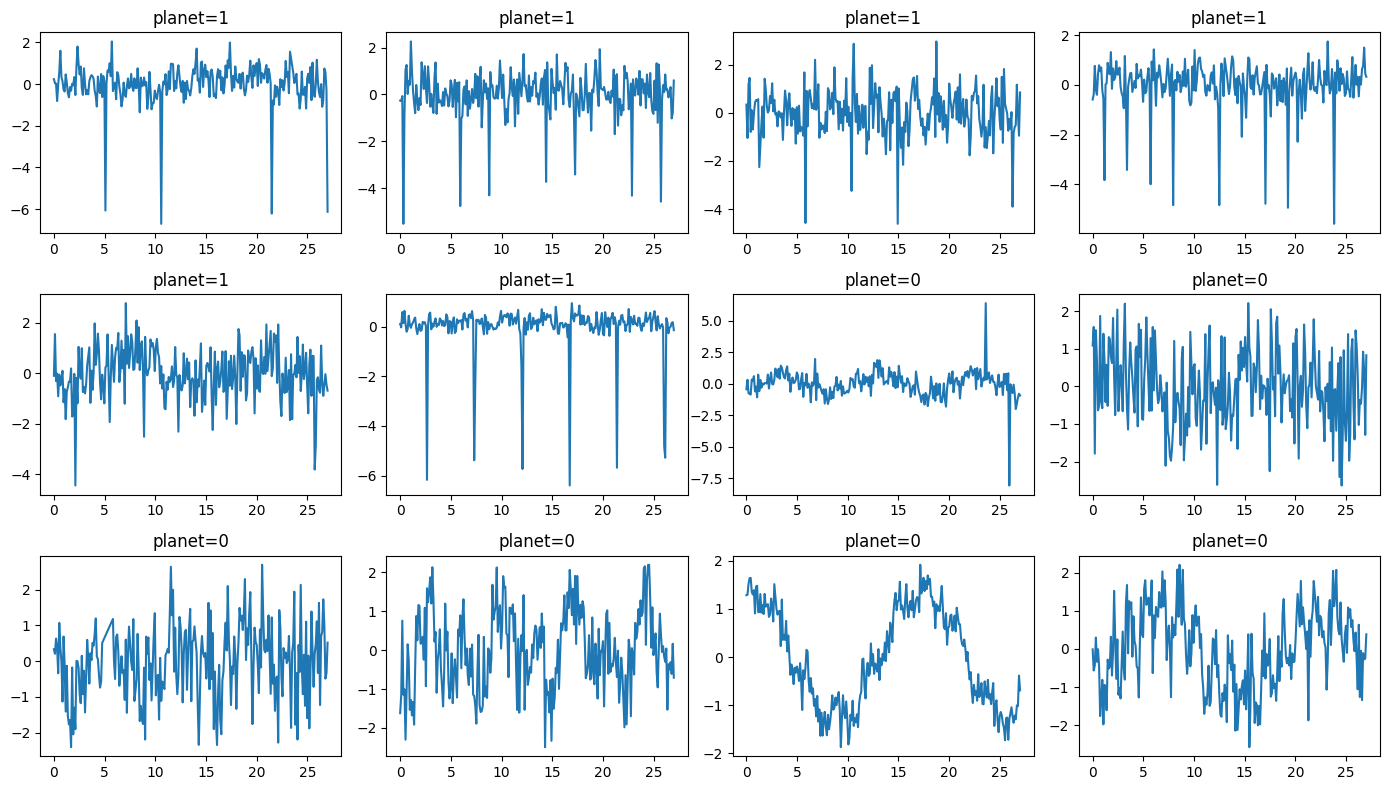

In [22]:
fig, axes = plt.subplots(3, 4, figsize=(14, 8))
axes = axes.flatten()

for i in range(12):
    label = i < 6
    t, f = simulate_example(label, n_points=256)
    axes[i].plot(t, f)
    axes[i].set_title(f"planet={int(label)}")

plt.tight_layout()
plt.show()

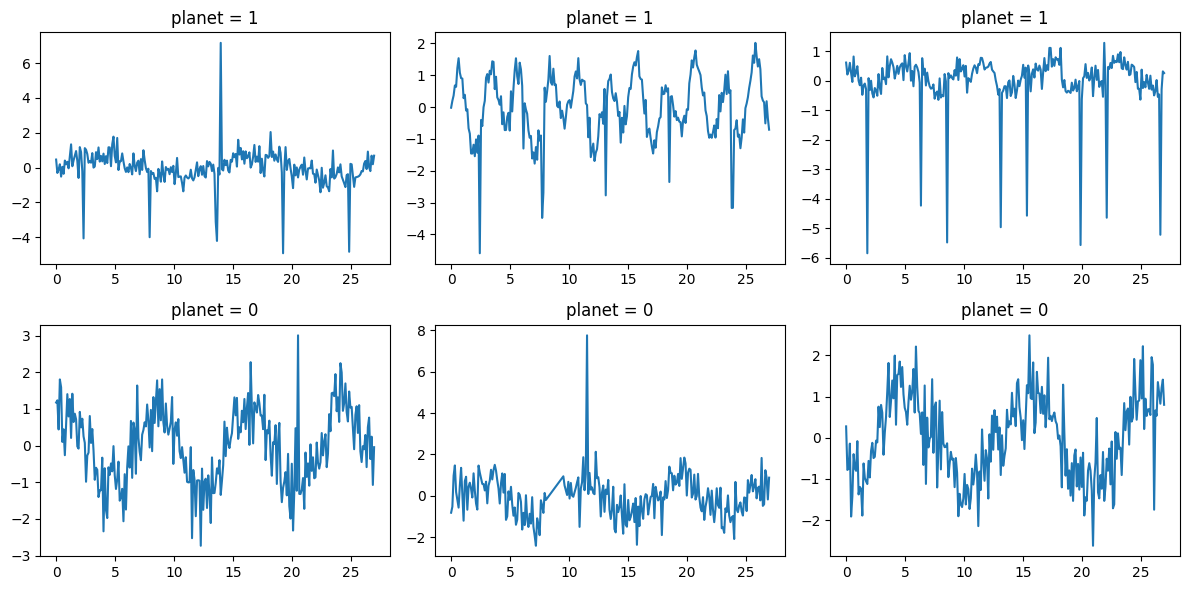

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))

for i in range(3):
    t, f = simulate_example(has_planet=1)
    axes[0, i].plot(t, f)
    axes[0, i].set_title("planet = 1")

for i in range(3):
    t, f = simulate_example(has_planet=0)
    axes[1, i].plot(t, f)
    axes[1, i].set_title("planet = 0")

plt.tight_layout()
plt.show()

In [24]:
def build_dataset(n_samples=4000, n_points=256):
    X, y = [], []
    for _ in range(n_samples):
        label = np.random.randint(0, 2)
        _, flux = simulate_example(bool(label), n_points=n_points)
        X.append(flux)
        y.append(label)

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)
    return X, y

X, y = build_dataset(n_samples=10000, n_points=256)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(X_train.shape, X_val.shape, X_test.shape)

(7000, 256) (1500, 256) (1500, 256)


In [25]:
class TransitDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X).unsqueeze(1)  # (N, 1, L)
        self.y = torch.tensor(y).float()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = TransitDataset(X_train, y_train)
val_ds   = TransitDataset(X_val, y_val)
test_ds  = TransitDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=128, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=128, shuffle=False)

In [26]:
class TransitCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=9, padding=4),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            nn.Conv1d(128,128, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x.squeeze(1)

model = TransitCNN().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

In [27]:
def evaluate_loss(model, loader):
    model.eval()
    total_loss = 0.0
    n = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * len(xb)
            n += len(xb)
    return total_loss / n

best_val = float("inf")
best_path = "/content/best_transit_cnn.pt"

for epoch in range(30):
    model.train()
    total_loss = 0.0
    n = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(xb)
        n += len(xb)

    train_loss = total_loss / n
    val_loss = evaluate_loss(model, val_loader)

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), best_path)

    print(f"Epoch {epoch+1:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

Epoch 01 | train_loss=0.2464 | val_loss=0.2900
Epoch 02 | train_loss=0.1451 | val_loss=0.4133
Epoch 03 | train_loss=0.1297 | val_loss=0.1686
Epoch 04 | train_loss=0.1161 | val_loss=0.1290
Epoch 05 | train_loss=0.1057 | val_loss=0.1483
Epoch 06 | train_loss=0.1060 | val_loss=0.3441
Epoch 07 | train_loss=0.1081 | val_loss=0.2173
Epoch 08 | train_loss=0.1003 | val_loss=0.1700
Epoch 09 | train_loss=0.0831 | val_loss=0.1395
Epoch 10 | train_loss=0.0771 | val_loss=0.1432
Epoch 11 | train_loss=0.0735 | val_loss=0.1908
Epoch 12 | train_loss=0.0718 | val_loss=0.1255
Epoch 13 | train_loss=0.0583 | val_loss=0.1470
Epoch 14 | train_loss=0.0582 | val_loss=0.2401
Epoch 15 | train_loss=0.0546 | val_loss=0.1611
Epoch 16 | train_loss=0.0398 | val_loss=0.2597
Epoch 17 | train_loss=0.0270 | val_loss=0.2143
Epoch 18 | train_loss=0.0454 | val_loss=0.2773
Epoch 19 | train_loss=0.0169 | val_loss=0.2525
Epoch 20 | train_loss=0.0212 | val_loss=0.4571
Epoch 21 | train_loss=0.0190 | val_loss=0.7066
Epoch 22 | tr

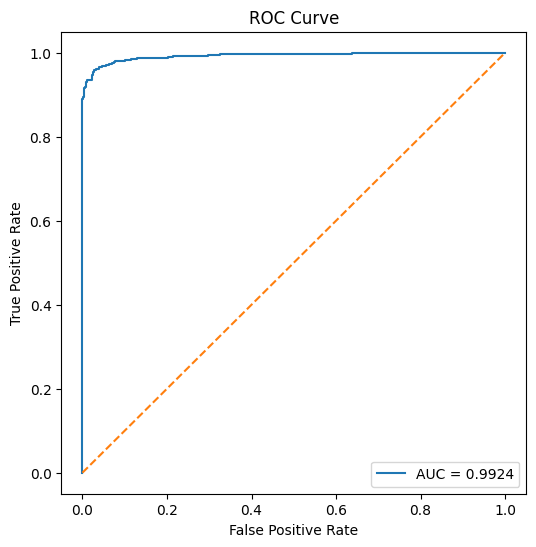

AUC: 0.9924044691307099
              precision    recall  f1-score   support

         0.0     0.9488    0.9776    0.9630       758
         1.0     0.9764    0.9461    0.9610       742

    accuracy                         0.9620      1500
   macro avg     0.9626    0.9618    0.9620      1500
weighted avg     0.9624    0.9620    0.9620      1500



In [28]:
model.load_state_dict(torch.load(best_path, map_location=device))
model.eval()

all_probs = []
all_true = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.extend(probs.tolist())
        all_true.extend(yb.numpy().tolist())

fpr, tpr, _ = roc_curve(all_true, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

pred = (np.array(all_probs) >= 0.5).astype(int)
print("AUC:", roc_auc)
print(classification_report(all_true, pred, digits=4))

In [29]:
def predict_single_flux(model, flux_1d):
    model.eval()
    flux_1d = np.asarray(flux_1d, dtype=np.float32)
    flux_1d = (flux_1d - flux_1d.mean()) / (flux_1d.std() + 1e-8)
    x = torch.tensor(flux_1d).unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        logit = model(x)
        prob = torch.sigmoid(logit).item()

    return {
        "prob_planet": prob,
        "pred_label": int(prob >= 0.5)
    }